# 10. Customer Clustering

## 1. Setup and Load Dataset

In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data_loader import load_data, save_file

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Python version: 3.10.11
Pandas version: 2.1.4
NumPy version: 1.26.4


In [16]:
# Load data using custom loader
try:
    df = load_data('data/processed/electricity_data_cleaned.parquet')
    print("✅ Data loaded successfully!")
    print(f"📊 Shape: {df.shape}")
    print(f"🕒 Time span: {df.index.min()} → {df.index.max()}")
    if not df.index.freq:
        df = df.asfreq("1H")
    print(f"🕒 Frequency: {df.index.freq}")
except Exception as e:
    print(f"❌ Error: {e}")

👉 Loading: data/processed/electricity_data_cleaned.parquet
✅ Data loaded successfully!
📊 Shape: (35065, 370)
🕒 Time span: 2011-01-01 00:00:00 → 2015-01-01 00:00:00
🕒 Frequency: <Hour>


In [19]:
tmp = df.copy()
tmp['_hour']  = tmp.index.hour          # 0-23
tmp['_month'] = tmp.index.month         # 1-12
tmp['_season'] = tmp['_month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
     3:'Spring', 4:'Spring', 5:'Spring',
     6:'Summer', 7:'Summer', 8:'Summer',
     9:'Autumn',10:'Autumn',11:'Autumn',
})

customers = df.columns.tolist()         # [MT_001, MT_002, ...]

rows = []

# Extract peak/off-peak hours, peak month, and season for each customer
for cust in customers:
    # mean consumption by hour (0-23)
    hourly_avg = tmp.groupby('_hour')[cust].mean()
    peak_hour     = int(hourly_avg.idxmax())   # hour with highest avg
    offpeak_hour  = int(hourly_avg.idxmin())   # hour with lowest avg

    # mean consumption by month (1-12)
    monthly_avg = tmp.groupby('_month')[cust].mean()
    peak_month  = int(monthly_avg.idxmax())    # month number (1-12)
    peak_month_name = pd.Timestamp(2000, peak_month, 1).strftime('%B')

    # season that contains the peak month
    peak_season = tmp.loc[tmp['_month'] == peak_month, '_season'].iloc[0]

    rows.append({
        'customer'      : cust,
        'peak_hour'     : peak_hour,  
        'offpeak_hour'  : offpeak_hour, 
        'peak_month'    : peak_month,
        'peak_month_name': peak_month_name,
        'peak_season'   : peak_season,
    })

profile_df = pd.DataFrame(rows).set_index('customer')
 

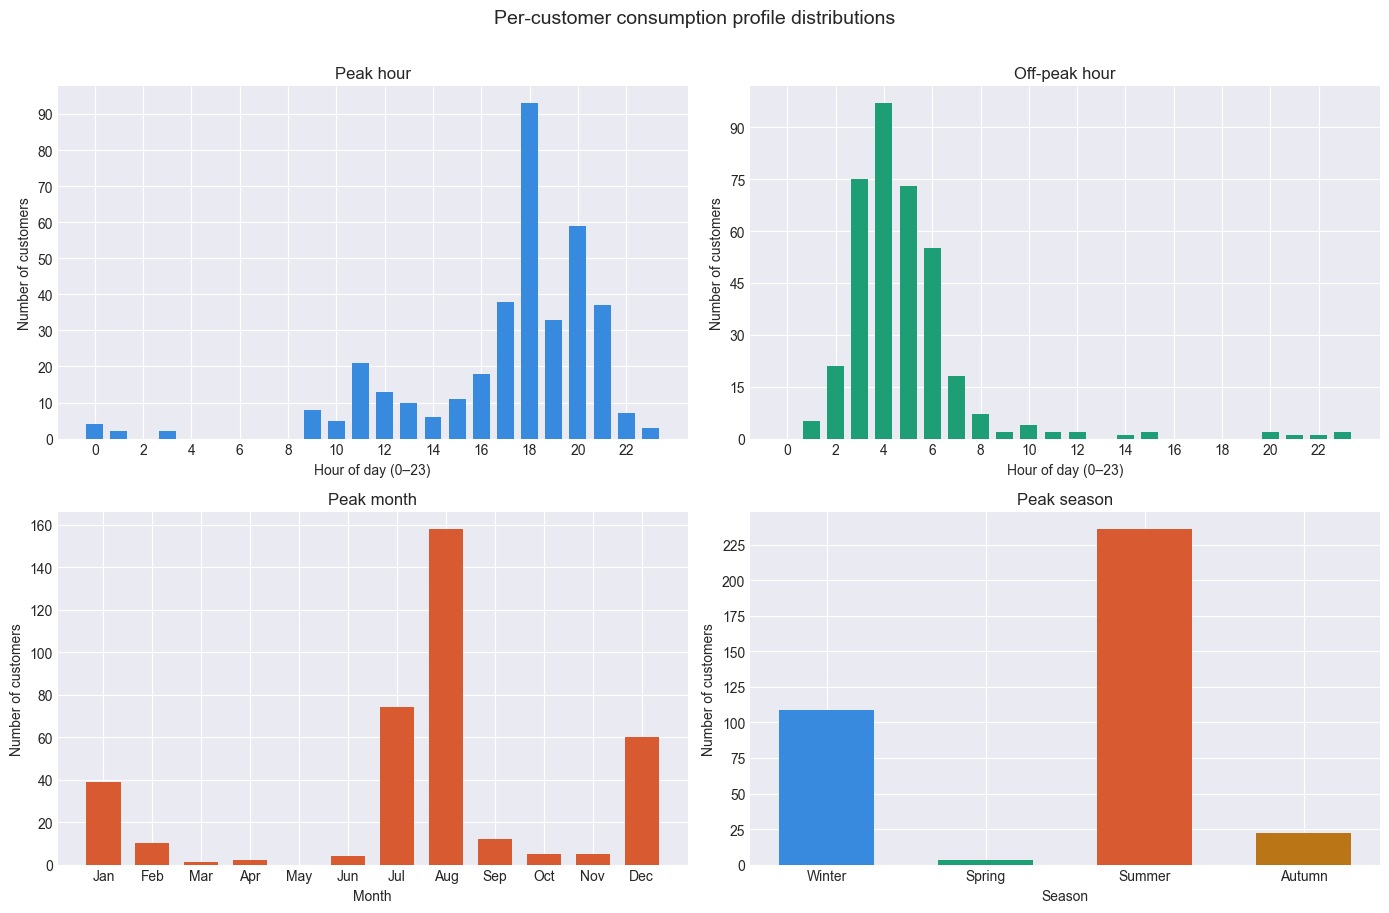

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Per-customer consumption profile distributions", fontsize=14, y=1.01)

# 1. Peak hour
ax = axes[0, 0]
peak_h = profile_df['peak_hour'].value_counts().reindex(range(24), fill_value=0)
ax.bar(peak_h.index, peak_h.values, color='#378ADD', width=0.7)
ax.set_xlabel("Hour of day (0–23)")
ax.set_ylabel("Number of customers")
ax.set_title("Peak hour")
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# 2. Off-peak hour
ax = axes[0, 1]
off_h = profile_df['offpeak_hour'].value_counts().reindex(range(24), fill_value=0)
ax.bar(off_h.index, off_h.values, color='#1D9E75', width=0.7)
ax.set_xlabel("Hour of day (0–23)")
ax.set_ylabel("Number of customers")
ax.set_title("Off-peak hour")
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# 3. Peak month
ax = axes[1, 0]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
peak_m = profile_df['peak_month'].value_counts().reindex(range(1, 13), fill_value=0)
ax.bar(month_labels, peak_m.values, color='#D85A30', width=0.7)
ax.set_xlabel("Month")
ax.set_ylabel("Number of customers")
ax.set_title("Peak month")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# 4. Peak season
ax = axes[1, 1]
season_order  = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517']
peak_s = profile_df['peak_season'].value_counts().reindex(season_order, fill_value=0)
ax.bar(season_order, peak_s.values, color=season_colors, width=0.6)
ax.set_xlabel("Season")
ax.set_ylabel("Number of customers")
ax.set_title("Peak season")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()